In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv(r"\Users\Anjli Kumari\datasets\titanic.csv",usecols=['Age','Fare','Survived'])

In [1]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       891 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [19]:
X = df.iloc[:,1:3]
Y = df.iloc[:,0]

In [20]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

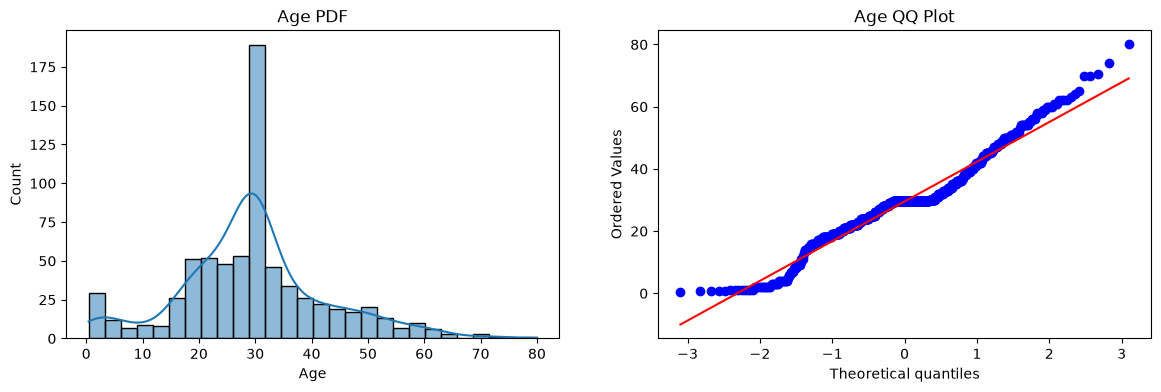

In [33]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Age'],kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ Plot')

plt.show()

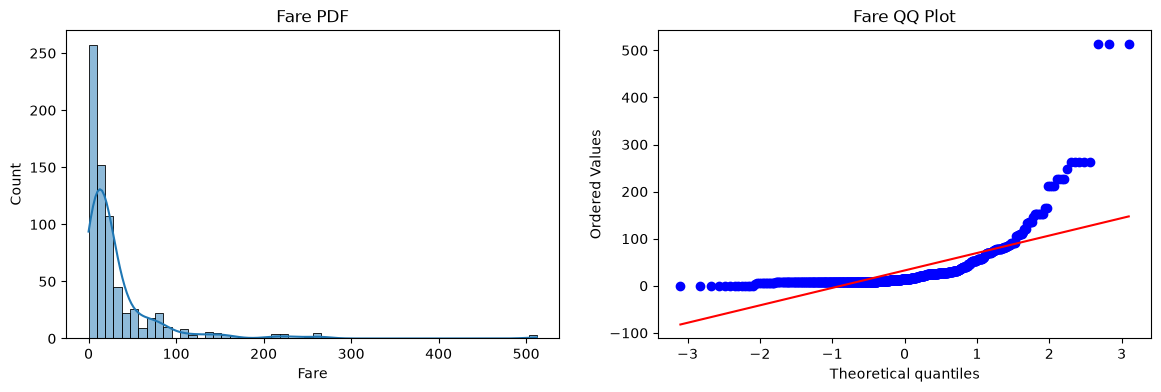

In [35]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [36]:
lr = LogisticRegression()
dtc = DecisionTreeClassifier()

In [37]:
lr.fit(X_train,Y_train)
dtc.fit(X_train,Y_train)
Y_pred_lr = lr.predict(X_test)
Y_pred_dtc = dtc.predict(X_test)
print("Accuracy Score of LR:",accuracy_score(Y_test,Y_pred_lr))
print("Accuracy Score of DTC:",accuracy_score(Y_test,Y_pred_dtc))

Accuracy Score of LR: 0.6480446927374302
Accuracy Score of DTC: 0.6703910614525139


In [39]:
transformer = FunctionTransformer(func=np.log1p)

In [40]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [41]:
lr = LogisticRegression()
dtc = DecisionTreeClassifier()

In [43]:
lr.fit(X_train_transformed,Y_train)
dtc.fit(X_train_transformed,Y_train)
Y_pred_lr = lr.predict(X_test_transformed)
Y_pred_dtc = dtc.predict(X_test_transformed)
print("Accuracy Score of LR:",accuracy_score(Y_test,Y_pred_lr))
print("Accuracy Score of DTC:",accuracy_score(Y_test,Y_pred_dtc))

Accuracy Score of LR: 0.6815642458100558
Accuracy Score of DTC: 0.6815642458100558


In [45]:
X_transformed = transformer.fit_transform(X_train)
lr = LogisticRegression()
dtc = DecisionTreeClassifier()
print("LR :",np.mean(cross_val_score(lr,X_transformed,Y_train,scoring='accuracy',cv=10)))
print("DTC :",np.mean(cross_val_score(dtc,X_transformed,Y_train,scoring='accuracy',cv=10)))

LR : 0.6783646322378717
DTC : 0.6249608763693271


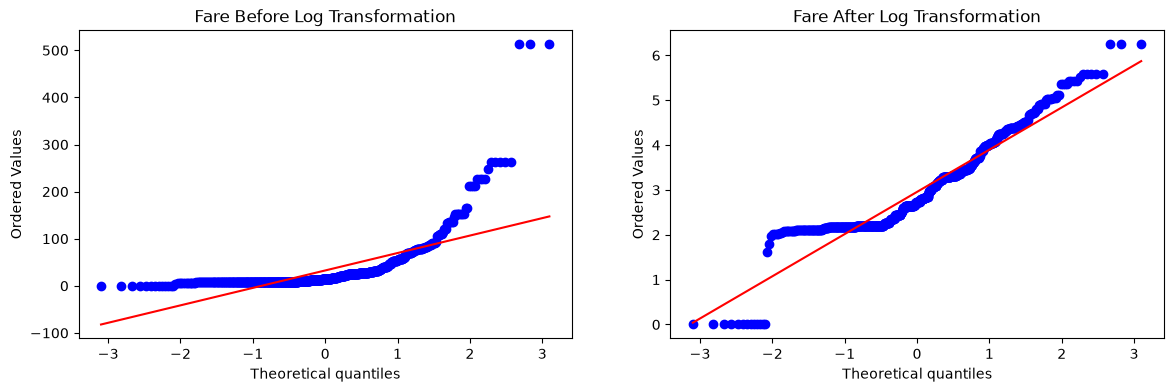

In [47]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare Before Log Transformation')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
plt.title('Fare After Log Transformation')

plt.show()

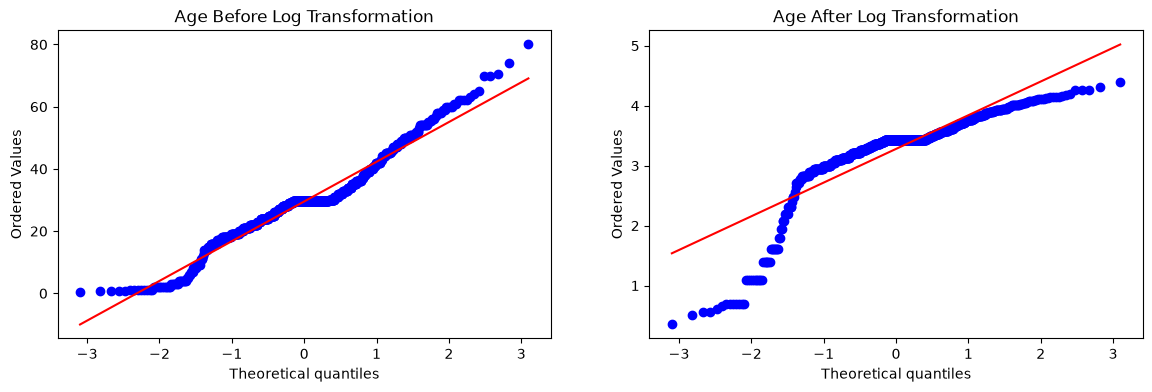

In [48]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age Before Log Transformation')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist='norm',plot=plt)
plt.title('Age After Log Transformation')

plt.show()

In [50]:
transformer2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')
X_train_transformed2 = transformer2.fit_transform(X_train)
X_test_transformed2 = transformer2.fit_transform(X_test)

In [51]:
lr = LogisticRegression()
dtc = DecisionTreeClassifier()
lr.fit(X_train_transformed2,Y_train)
dtc.fit(X_train_transformed2,Y_train)
Y_pred_lr2 = lr.predict(X_test_transformed2)
Y_pred_dtc2 = dtc.predict(X_test_transformed2)
print("Accuracy Score of LR:",accuracy_score(Y_test,Y_pred_lr2))
print("Accuracy Score of DTC:",accuracy_score(Y_test,Y_pred_dtc2))

Accuracy Score of LR: 0.6703910614525139
Accuracy Score of DTC: 0.6871508379888268


In [52]:
X_transformed2 = transformer2.fit_transform(X_train)
lr = LogisticRegression()
dtc = DecisionTreeClassifier()
print("LR :",np.mean(cross_val_score(lr,X_transformed2,Y_train,scoring='accuracy',cv=10)))
print("DTC :",np.mean(cross_val_score(dtc,X_transformed2,Y_train,scoring='accuracy',cv=10)))

LR : 0.6572378716744913
DTC : 0.6305946791862286


In [53]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6195131086142323


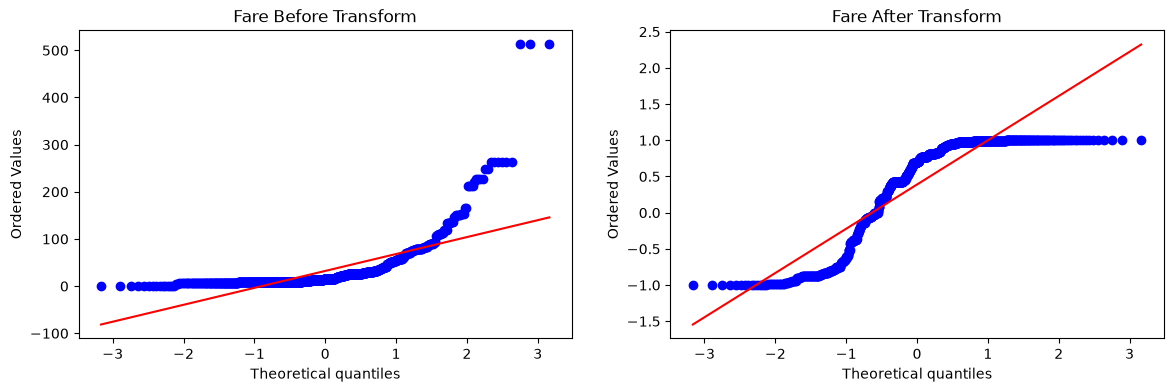

In [60]:
apply_transform(np.sin)